<a href="https://colab.research.google.com/github/mukesh-dev-git/mukesh-fs-ai-project/blob/main/notebooks/01_scene_analysis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image/Video Classification for Crime Scene Analysis — Colab pipeline

A simple, end-to-end baseline for AI-assisted crime scene analysis from photos and video:

| Stage | What it does | Model / tool |
|---|---|---|
| 1. Hashing | SHA-256 per file, perceptual-hash dedup, hash-chained audit log | `hashlib`, `imagehash` |
| 2. Masking | Black out people before any scene reasoning | YOLOv8n-seg |
| 3. Detection | Find evidence-relevant objects | YOLOv8s (COCO) |
| 4. Classification | Predict the incident type (14 UCF-Crime classes) | ResNet-18, fine-tuned |
| 5. VLM | Describe each masked view, grounded on stages 3–4 | Qwen2.5-VL-3B-Instruct |
| 6. Reconstruction | Contact sheet of all views → timeline, evidence, entry points, gaps | Qwen2.5-VL-3B-Instruct |

**Runtime:** `Runtime → Change runtime type → T4 GPU`.
**Before running:** add `KAGGLE_USERNAME` and `KAGGLE_KEY` in Colab *Secrets* (key icon in the left bar).

## 0. Setup

In [4]:
!pip install -q ultralytics imagehash qwen-vl-utils kagglehub
!pip install -q -U transformers accelerate
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [5]:
import os, re, json, time, random, hashlib
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
import imagehash
from PIL import Image, ImageDraw

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 1. Dataset — UCF-Crime frames (Kaggle, CC0)

Frames extracted from the UCF-Crime surveillance videos (every 10th frame, 64×64 PNG), 14 classes:
Abuse, Arrest, Arson, Assault, Burglary, Explosion, Fighting, Normal Videos, RoadAccidents,
Robbery, Shooting, Shoplifting, Stealing, Vandalism. About 11.6 GB; the download takes a few minutes.

In [10]:
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

import kagglehub
DATA_DIR = Path(kagglehub.dataset_download("odins0n/ucf-crime-dataset"))

TRAIN = next(p for p in DATA_DIR.rglob("Train") if p.is_dir())
TEST = next(p for p in DATA_DIR.rglob("Test") if p.is_dir())
CLASSES = sorted(d.name for d in TRAIN.iterdir() if d.is_dir())
print(TRAIN, TEST)
print(len(CLASSES), "classes:", CLASSES)

100%|██████████| 11.0G/11.0G [02:05<00:00, 94.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Test
14 classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


## 2. Stage 1 — Hashing

Every file is SHA-256 hashed on arrival. Near-duplicate frames are dropped using a perceptual hash.
Every action goes into an append-only log where each entry carries the hash of the previous entry,
so any later edit to the log is detectable (`log.verify()`).

In [11]:
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


class AuditLog:
    """Append-only, hash-chained log of every pipeline action."""

    def __init__(self):
        self.entries = []

    def add(self, action, **details):
        prev = self.entries[-1]["entry_hash"] if self.entries else "0" * 64
        body = {"ts": time.time(), "action": action, "details": details, "prev_hash": prev}
        body["entry_hash"] = hashlib.sha256(json.dumps(body, sort_keys=True, default=str).encode()).hexdigest()
        self.entries.append(body)

    def verify(self):
        prev = "0" * 64
        for e in self.entries:
            body = {k: v for k, v in e.items() if k != "entry_hash"}
            digest = hashlib.sha256(json.dumps(body, sort_keys=True, default=str).encode()).hexdigest()
            if e["prev_hash"] != prev or digest != e["entry_hash"]:
                return False
            prev = e["entry_hash"]
        return True


def ingest(paths, log, dedup_threshold=4):
    """Hash each file, skip near-duplicates (pHash distance <= threshold), log everything."""
    kept, seen = [], []
    for p in paths:
        digest = sha256_file(p)
        ph = imagehash.phash(Image.open(p).convert("RGB"))
        if any(ph - s <= dedup_threshold for s in seen):
            log.add("skip_duplicate", file=str(p), sha256=digest)
            continue
        seen.append(ph)
        kept.append({"path": str(p), "sha256": digest, "phash": str(ph)})
        log.add("ingest", file=str(p), sha256=digest, phash=str(ph))
    return kept

### Build a demo case

A *case* is a set of views of one incident. Here we take evenly spaced frames from one test video.
Frame files are grouped by video using the filename (`<video>_<frame>.png`); if the pattern does not
match, the frames are used in name order. To analyse your own photos or video, see the last section.

In [12]:
FRAME_RE = re.compile(r"(.+?)_(\d+)\.png$")

def frames_by_video(class_dir):
    groups = defaultdict(list)
    for p in class_dir.glob("*.png"):
        m = FRAME_RE.match(p.name)
        key, idx = (m.group(1), int(m.group(2))) if m else ("all", 0)
        groups[key].append((idx, p.name, p))
    return {k: [p for _, _, p in sorted(v)] for k, v in groups.items()}

random.seed(7)
CASE_CLASS = "Burglary"
videos = frames_by_video(TEST / CASE_CLASS)
case_id = random.choice(sorted(videos))
frames = videos[case_id]
case_paths = frames[:: max(1, len(frames) // 12)][:12]
print(case_id, "-", len(frames), "frames,", len(case_paths), "selected")

log = AuditLog()
log.add("create_case", case_id=case_id, source=f"UCF-Crime test/{CASE_CLASS}")
case = ingest(case_paths, log)
print(len(case), "views kept after dedup | audit log valid:", log.verify())

Burglary032_x264 - 1580 frames, 12 selected
10 views kept after dedup | audit log valid: True


## 3. Stages 2–3 — Masking and detection

People are segmented with YOLOv8n-seg and filled black, so later stages (the VLM) never see them.
Evidence objects are detected with a COCO-pretrained YOLOv8s. COCO has no *gun* class; fine-tuning
on the OD-WeaponDetection dataset is the next step (see `datasets/README.md`).

In [13]:
from ultralytics import YOLO

seg_model = YOLO("yolov8n-seg.pt")
det_model = YOLO("yolov8s.pt")

EVIDENCE = {"knife", "scissors", "baseball bat", "bottle", "cell phone", "handbag",
            "backpack", "suitcase", "car", "motorcycle", "truck", "bicycle"}

def mask_people(img_bgr):
    """Return a copy with every detected person filled black, and the count."""
    r = seg_model(img_bgr, classes=[0], verbose=False)[0]
    out = img_bgr.copy()
    if r.masks is None:
        return out, 0
    mask = np.zeros(img_bgr.shape[:2], np.uint8)
    for poly in r.masks.xy:
        if len(poly):
            cv2.fillPoly(mask, [poly.astype(np.int32)], 255)
    out[mask > 0] = 0
    return out, len(r.masks.xy)

def detect_evidence(img_bgr, conf=0.25):
    r = det_model(img_bgr, conf=conf, verbose=False)[0]
    found = []
    for b in r.boxes:
        name = r.names[int(b.cls)]
        if name in EVIDENCE:
            found.append({"label": name, "conf": round(float(b.conf), 2),
                          "box": [round(v) for v in b.xyxy[0].tolist()]})
    return found

for item in case:
    img = cv2.imread(item["path"])
    item["masked"], item["people_masked"] = mask_people(img)
    item["evidence"] = detect_evidence(img)
    log.add("analyse", sha256=item["sha256"], people_masked=item["people_masked"], evidence=item["evidence"])
    print(Path(item["path"]).name, "| people masked:", item["people_masked"], "| evidence:", item["evidence"])

Burglary032_x264_0.png | people masked: 0 | evidence: []
Burglary032_x264_1310.png | people masked: 0 | evidence: []
Burglary032_x264_2620.png | people masked: 0 | evidence: []
Burglary032_x264_3930.png | people masked: 0 | evidence: []
Burglary032_x264_5240.png | people masked: 0 | evidence: []
Burglary032_x264_6550.png | people masked: 0 | evidence: []
Burglary032_x264_7860.png | people masked: 0 | evidence: []
Burglary032_x264_9170.png | people masked: 0 | evidence: []
Burglary032_x264_10480.png | people masked: 0 | evidence: []
Burglary032_x264_11790.png | people masked: 0 | evidence: []


## 4. Stage 4 — Incident-type classification

Fine-tune an ImageNet ResNet-18 on a class-balanced sample of the training frames
(3,000 per class by default), then evaluate on the official test split.

In [14]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

def sample(split_dir, per_class, seed=0):
    rng = random.Random(seed)
    items = []
    for i, c in enumerate(CLASSES):
        files = sorted((split_dir / c).glob("*.png"))
        items += [(p, i) for p in rng.sample(files, min(per_class, len(files)))]
    return items

class Frames(Dataset):
    def __init__(self, items, tf):
        self.items, self.tf = items, tf
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        return self.tf(Image.open(p).convert("RGB")), y

NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = transforms.Compose([transforms.Resize((112, 112)), transforms.RandomHorizontalFlip(),
                               transforms.ColorJitter(0.2, 0.2), transforms.ToTensor(), NORM])
tf_eval = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor(), NORM])

train_dl = DataLoader(Frames(sample(TRAIN, 3000), tf_train), batch_size=128, shuffle=True, num_workers=2)
test_dl = DataLoader(Frames(sample(TEST, 500), tf_eval), batch_size=256, num_workers=2)

clf = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
clf.fc = nn.Linear(clf.fc.in_features, len(CLASSES))
clf = clf.to(device)
opt = torch.optim.AdamW(clf.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 3
for epoch in range(EPOCHS):
    clf.train()
    total, n = 0.0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(clf(x), y)
        loss.backward()
        opt.step()
        total, n = total + loss.item() * len(y), n + len(y)
    print(f"epoch {epoch + 1}/{EPOCHS}  train loss {total / n:.3f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


epoch 1/3  train loss 0.308
epoch 2/3  train loss 0.055
epoch 3/3  train loss 0.043


In [15]:
from sklearn.metrics import classification_report

clf.eval()
preds, gts = [], []
with torch.no_grad():
    for x, y in test_dl:
        preds += clf(x.to(device)).argmax(1).cpu().tolist()
        gts += y.tolist()
print(classification_report(gts, preds, labels=list(range(len(CLASSES))),
                            target_names=CLASSES, digits=3, zero_division=0))

               precision    recall  f1-score   support

        Abuse      0.063     0.024     0.034       297
       Arrest      0.116     0.022     0.037       500
        Arson      0.183     0.298     0.227       500
      Assault      0.027     0.016     0.020       500
     Burglary      0.200     0.190     0.195       500
    Explosion      0.293     0.034     0.061       500
     Fighting      0.151     0.110     0.127       500
 NormalVideos      0.213     0.358     0.267       500
RoadAccidents      0.289     0.470     0.358       500
      Robbery      0.094     0.154     0.117       500
     Shooting      0.009     0.002     0.003       500
  Shoplifting      0.195     0.108     0.139       500
     Stealing      0.119     0.160     0.136       500
    Vandalism      0.000     0.000     0.000       500

     accuracy                          0.142      6797
    macro avg      0.139     0.139     0.123      6797
 weighted avg      0.142     0.142     0.126      6797



In [16]:
def classify(img_bgr, k=3):
    x = tf_eval(Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))).unsqueeze(0).to(device)
    with torch.no_grad():
        p = clf(x).softmax(1)[0]
    top = p.topk(k)
    return [(CLASSES[i], round(float(s), 3)) for s, i in zip(top.values.tolist(), top.indices.tolist())]

votes = defaultdict(float)
for item in case:
    item["scene_top3"] = classify(cv2.imread(item["path"]))
    for c, s in item["scene_top3"]:
        votes[c] += s
case_label = max(votes, key=votes.get)
log.add("classify", case_label=case_label, votes=dict(votes))
print("Case-level incident type:", case_label)

Case-level incident type: Vandalism


## 5. Stage 5 — VLM description of each view

Qwen2.5-VL-3B-Instruct (fp16, about 8 GB) sees only the **masked** image, plus the detector and
classifier output as grounding. The prompt tells it to describe only what is visible and to say
*uncertain* otherwise.

In [18]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

VLM_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
vlm = Qwen2_5_VLForConditionalGeneration.from_pretrained(VLM_ID, torch_dtype=torch.float16, device_map="auto")
proc = AutoProcessor.from_pretrained(VLM_ID)

def ask_vlm(images, prompt, max_new_tokens=512):
    content = [{"type": "image", "image": im} for im in images] + [{"type": "text", "text": prompt}]
    messages = [{"role": "user", "content": content}]
    text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = proc(text=[text], images=image_inputs, videos=video_inputs,
                  padding=True, return_tensors="pt").to(vlm.device)
    out = vlm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return proc.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()

def to_pil(img_bgr, size=448):
    return Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)).resize((size, size))

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [19]:
for n, item in enumerate(case, 1):
    prompt = (
        f"This is view #{n} of a possible crime scene. People are blacked out for privacy; "
        "never guess who they are.\n"
        f"Object detector output: {json.dumps(item['evidence']) if item['evidence'] else 'none'}\n"
        f"Scene classifier top-3: {item['scene_top3']}\n"
        "In at most 3 short bullet points, describe only what is visible: objects, damage, "
        "and anything out of place. Write 'uncertain' when you are not sure."
    )
    item["description"] = ask_vlm([to_pil(item["masked"])], prompt, max_new_tokens=200)
    log.add("describe", sha256=item["sha256"], description=item["description"])
    print(f"#{n}\n{item['description']}\n")

#1
- Uncertain
- Uncertain
- Uncertain

#2
- Uncertain
- Uncertain
- Uncertain

#3
- Uncertain
- Uncertain
- Uncertain

#4
- Uncertain
- Uncertain
- Uncertain

#5
- Uncertain
- Uncertain
- Uncertain

#6
- Uncertain
- Uncertain
- Uncertain

#7
- Uncertain
- Uncertain
- Uncertain

#8
- Uncertain
- Uncertain
- Uncertain

#9
- Uncertain
- Uncertain
- Uncertain

#10
- Uncertain
- Uncertain
- Uncertain



## 6. Stage 6 — Scene reconstruction

All masked views are tiled into one contact sheet with numbered badges. The VLM gets the sheet plus
the per-view findings and must return JSON: a timeline, key evidence, entry-point verdicts
(`ruled_in` / `ruled_out` / `uncertain`) and gaps, citing view numbers for every claim.

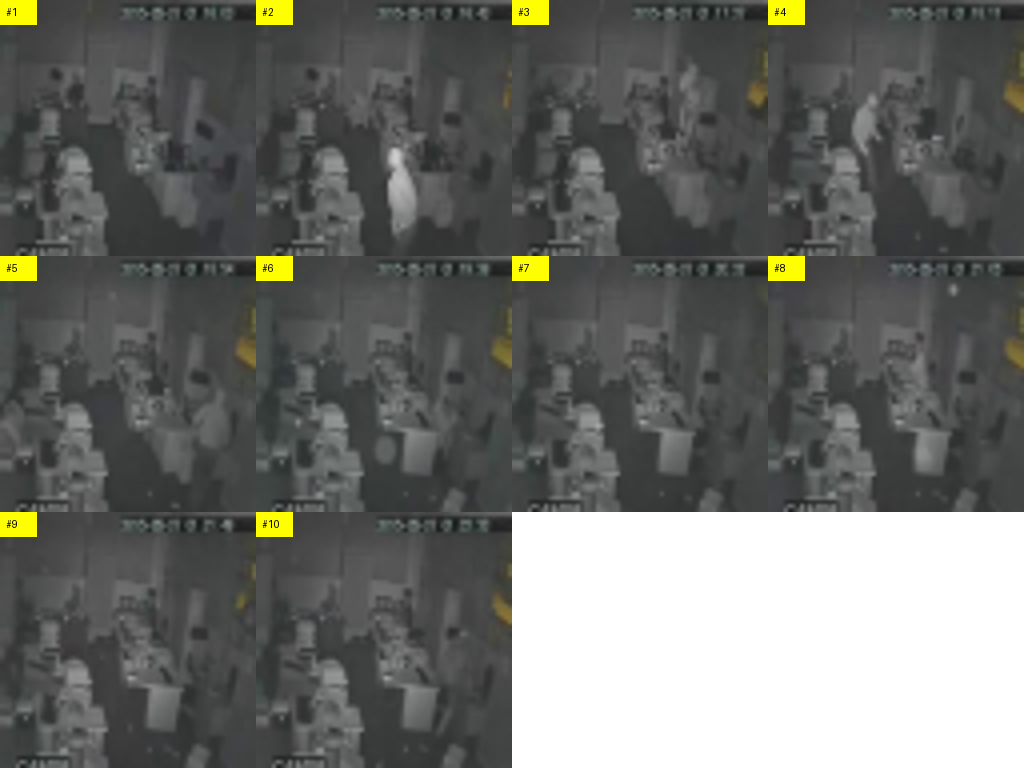

{
  "incident_type": "Vandalism",
  "timeline": [
    {
      "views": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10
      ],
      "event": "People gathered in an area, some holding signs or banners."
    }
  ],
  "key_evidence": [
    {
      "item": "Signs/banners held by people",
      "views": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10
      ]
    }
  ],
  "entry_points": [
    {
      "location": "Gathering area",
      "verdict": "ruled_in",
      "views": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10
      ]
    }
  ],
  "gaps": []
}


In [20]:
def contact_sheet(images, cols=4, tile=256):
    rows = (len(images) + cols - 1) // cols
    sheet = Image.new("RGB", (cols * tile, rows * tile), "white")
    draw = ImageDraw.Draw(sheet)
    for i, im in enumerate(images):
        x, y = (i % cols) * tile, (i // cols) * tile
        sheet.paste(im.resize((tile, tile)), (x, y))
        draw.rectangle([x, y, x + 36, y + 24], fill="yellow")
        draw.text((x + 6, y + 6), f"#{i + 1}", fill="black")
    return sheet

def parse_json(text):
    s, e = text.find("{"), text.rfind("}")
    try:
        return json.loads(text[s:e + 1])
    except ValueError:
        return {"unparsed": text}

sheet = contact_sheet([to_pil(it["masked"], 256) for it in case])
display(sheet)

findings = "\n".join(f"#{i}: evidence={it['evidence']}; notes={it['description']}" for i, it in enumerate(case, 1))
prompt = (
    "The image is a contact sheet of numbered views (#1, #2, ...) of one incident, in time order. "
    "People are blacked out.\n"
    f"Per-view findings:\n{findings}\n"
    f"Predicted incident type: {case_label}\n\n"
    "Reconstruct what most likely happened. Reply with JSON only, with keys: "
    '"incident_type"; "timeline": [{"views": [numbers], "event": text}]; '
    '"key_evidence": [{"item": text, "views": [numbers]}]; '
    '"entry_points": [{"location": text, "verdict": "ruled_in" | "ruled_out" | "uncertain", "views": [numbers]}]; '
    '"gaps": [text]. Cite view numbers for every claim and do not invent facts.'
)
reconstruction = parse_json(ask_vlm([sheet], prompt, max_new_tokens=800))
log.add("reconstruct", result=reconstruction)
print(json.dumps(reconstruction, indent=2))

## 7. Export the case report and check the audit log

In [21]:
report = {
    "case_id": case_id,
    "incident_type": case_label,
    "views": [{k: v for k, v in it.items() if k != "masked"} for it in case],
    "reconstruction": reconstruction,
    "audit_log": log.entries,
    "audit_log_valid": log.verify(),
}
Path("case_report.json").write_text(json.dumps(report, indent=2, default=str))
print("saved case_report.json | audit log valid:", report["audit_log_valid"])

# Tamper demo: change one past entry and the chain no longer verifies.
original = log.entries[1]["action"]
log.entries[1]["action"] = "tampered"
print("after editing entry 1, audit log valid:", log.verify())
log.entries[1]["action"] = original

saved case_report.json | audit log valid: True
after editing entry 1, audit log valid: False


## 8. Optional — analyse your own case (photos or a video)

Upload photos, or a video that is cut into one keyframe per second, then re-run from
**Build a demo case → ingest** onward (stages 2–7).

In [ ]:
def video_keyframes(video_path, out_dir="keyframes", every_sec=1.0):
    Path(out_dir).mkdir(exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    step = max(1, int((cap.get(cv2.CAP_PROP_FPS) or 25) * every_sec))
    saved, i = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if i % step == 0:
            p = Path(out_dir) / f"frame_{i:06d}.jpg"
            cv2.imwrite(str(p), frame)
            saved.append(p)
        i += 1
    cap.release()
    return saved

# from google.colab import files
# uploaded = list(files.upload())
# case_paths = video_keyframes(uploaded[0]) if uploaded[0].lower().endswith((".mp4", ".avi", ".mov", ".mkv")) \
#              else [Path(n) for n in uploaded]
# case_id = "my_case"
# log = AuditLog(); log.add("create_case", case_id=case_id, source="upload")
# case = ingest(case_paths, log)